<div style="display: flex; background-color: #93C572; border: 5px solid #5D4037;">
<h1 style="margin: auto; padding: 30px; color: #000000;"> Etude de marché du poulet biologique 🐔🍀</h1>
</div>

<div style="border: 3px solid #CC7722;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #93C572; ">Préparation de l'environnement 📒</h3>
</div>

In [2]:
#Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.ticker
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px
from pathlib import Path
import plotly.subplots as sp
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist


#Import data
df_da= pd.read_csv(r"C:\Users\chris\Documents\GitHub\OC\P11\DataRaw\DisponibiliteAlimentaire_2017.csv", encoding='UTF-8', sep=',')
df_population= pd.read_csv(r"C:\Users\chris\Documents\GitHub\OC\P11\DataRaw\Population_2000_2018.csv", encoding='UTF-8', sep=',')
df_logistique= pd.read_csv(r"C:\Users\chris\Documents\GitHub\OC\P11\DataRaw\Indice_logistique_2017.csv", encoding='latin-1', sep=';')
df_PIB_STAB_SA= pd.read_csv(r"C:\Users\chris\Documents\GitHub\OC\P11\DataRaw\FAOSTAT_data_PIB_STAB_2017.csv", encoding='latin-1', sep=';')
df_agri_PIB= pd.read_csv(r"C:\Users\chris\Documents\GitHub\OC\P11\DataRaw\agri_PIB_2017.csv", encoding='latin-1', sep=';')

#Color Theme
theme1 = mcolors.LinearSegmentedColormap.from_list("", ["#93C572", "#E2B49A", "#CC7722", "#5D4037"])
theme2 = mcolors.LinearSegmentedColormap.from_list("", ["#93C572", "#F7B05B", "#5D4037", "#4F7942", "#E2B49A", "#CC7722"])

<div style="border: 3px solid #CC7722;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #93C572; "> Informations des tables</h3>
</div>

In [4]:
df_da.info()
df_agri_PIB.info()
df_logistique.info()
df_PIB_STAB_SA.info()
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  object 
 1   Domaine                 176600 non-null  object 
 2   Code zone               176600 non-null  int64  
 3   Zone                    176600 non-null  object 
 4   Code Élément            176600 non-null  int64  
 5   Élément                 176600 non-null  object 
 6   Code Produit            176600 non-null  int64  
 7   Produit                 176600 non-null  object 
 8   Code année              176600 non-null  int64  
 9   Année                   176600 non-null  int64  
 10  Unité                   176600 non-null  object 
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  object 
 13  Description du Symbole  176600 non-null  object 
dtypes: float64(1), int64

<div style="border: 3px solid #CC7722;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #93C572; "> Définition de la stratégie 🧠</h3>
</div>

Analyse PESTEL

| Axe | Variable | Justification | Daraframe |
| :--- | :--- | :--- | :--- |
| **Politique** | Stabilité politique (WGI) | Un pays instable = risque contractuel et douanier élevé | df_PIB_STAB_SA |
| **Economique** | PIB/habitant (USD) | Proxy du pouvoir d'achat — marché bio = segment premium | df_PIB_STAB_SA |
| **Economique** | Importations volaille (t) | Mesure la dépendance aux achats extérieurs = opportunité d'entrée | df_da |
| **Economique** | Exportations volaille (t) | Mesure la compétitivité locale — fort export = marché concurrentiel |df_da |
| **Social** | Population totale | Taille du marché potentiel | df_population |
| **Social** | Disponibilité kcal/personne/jour | Niveau de sécurité alimentaire — impact sur la propension à payer du bio | df_da |
| **Social** | Consommation volaille kg/hab/an | Habitude de consommation directement liée au produit | df_da |
| **Technologique** | Indice logistique LPI | Capacité d'un pays à recevoir et distribuer des produits réfrigérés | df_logistique |
| **Environnemental** | Part agriculture dans PIB (%) | Proxy de la concurrence locale en production animale | df_ |

### Sources des tables

| Axe | Variable | Source |
| :--- | :--- | :--- |
| **P** | Stabilité politique | Banque mondiale |
| **E** | PIB/habitant | Banque mondiale |
| **E** | Importations volaille (quantité) | FAO |
| **E** | Exportations volaille (quantité) | FAO |
| **S** | Population totale | FAO |
| **S** | Disponibilité kcal/personne/jour | FAO |
| **T** | Consommation volaille/habitant | FAO |
| **L** | Indice de facilité des affaires | Banque mondiale |
| **E(nv)** | Superficie agricole | FAO |

<div style="border: 3px solid #CC7722;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #93C572; ">Nettoyage et création du fichier 📒</h3>
</div>

### Importation, nettoyage et jointure des tables

- Filtrage de toutes les tables sur l'année 2017,
- Harmonisation des tables,
- Suppression des lignes sans données,
- Jointure des tables,
- Enregistrement du fichier

In [5]:
df_agri_PIB.head()

,Zone,"Agriculture, valeur ajoutée (part du PIB)"
0,Aruba,0.023919
1,Afghanistan,26.420199
2,Angola,14.928326
3,Albanie,18.079078
4,Andorre,0.559539


In [6]:
#Filtrer les tables sur 2017
df_population= df_population[df_population['Année'] == 2017].copy()
df_PIB_STAB_SA= df_PIB_STAB_SA[df_PIB_STAB_SA['Année'] == 2017].copy() 

#Filtrer la table de disponibilité alimentaire sur la volaille
df_da = df_da[df_da['Produit']=='Viande de Volailles'].copy()

#Renommer les colonnes
df_population.rename(columns={'Valeur':'Population'}, inplace=True)

#Modifier la colonne valeur en numérique
df_PIB_STAB_SA['Valeur'] = (df_PIB_STAB_SA ['Valeur']
    .astype(str)
    .str.replace(' ', '', regex=False)   # supprime les espaces
    .str.replace(',', '.', regex=False)  # virgule → point
    .astype(float)
)

df_logistique['LPI'] = (df_logistique ['LPI']
    .astype(str)
    .str.replace(' ', '', regex=False)   # supprime les espaces
    .str.replace(',', '.', regex=False)  # virgule → point
    .astype(float)
)

df_agri_PIB['Agriculture, valeur ajoutée (part du PIB)'] = (df_agri_PIB ['Agriculture, valeur ajoutée (part du PIB)'].astype(float)
)

In [7]:
#Harmonisation de la table de disponibilité alimentaire pour faciliter les analyses
df_da = df_da.pivot_table(
    index='Zone',
    columns='Élément',
    values='Valeur',
    aggfunc='mean'
).reset_index()

df_da.columns.name = None  # Nettoie le nom de l'axe colonnes

#Harmonisation de la table de PIB et sous-alimentatiom pour faciliter les analyses
df_PIB_STAB_SA = df_PIB_STAB_SA.pivot_table(
    index='Zone',
    columns='Produit',
    values='Valeur',
    aggfunc='mean'
).reset_index()

In [8]:
#Suppression des colonnes inutiles
df_da = df_da[['Zone', 'Disponibilité alimentaire en quantité (kg/personne/an)','Exportations - Quantité',
       'Importations - Quantité']].copy()

df_population = df_population[['Zone', 'Population']].copy()


In [9]:
#Fusion des dataframes

df_final = (df_da
    .merge(df_logistique,  on='Zone', how='left')
    .merge(df_PIB_STAB_SA,   on='Zone', how='left')
    .merge(df_population,  on='Zone', how='left')
    .merge(df_agri_PIB,  on='Zone', how='left')
)

In [10]:
#Rennomer les colonnes du df_final
RENAME = {
    'Zone': 'Pays',
    'Disponibilité alimentaire en quantité (kg/personne/an)': 'Conso_volaille_kg',
    'Exportations - Quantité'                               : 'Exports_t',
    'Importations - Quantité'                               : 'Imports_t',
    'LPI'                                                   : 'LPI',
    'PIB par habitant, ($ PPA internationaux constants de 2021)': 'PIB_hab',
    'Stabilité politique et absence de violence/terrorisme (indice)': 'Stabilite_pol',
    'Population'                                            : 'Population',
}
df_final = df_final.rename(columns=RENAME)



In [11]:
df_final.dropna(inplace=True)

In [12]:
#Enregistrement au format csv
df_final.to_csv(r"C:\Users\chris\Documents\GitHub\OC\P11\DataClean\df_finalV2.csv", index=False, encoding='UTF-8')

<div style="border: 3px solid #CC7722;border-radius: 8px" >
<h3 style="margin: auto; padding: 20px; color: #93C572; "> Analyse des données 📒</h3>
</div>

## Analyse exploratoire du fichier

- Unités:
    Conso_volaille: kg par personne et par année
    Export: milliers de tonnes
    Import: millier de tonnes
    LPI:indice logistique
    
- Information du dataframe sans valeur nulle
- Analyse exploratoire des données:
1. Statistiques descriptives
2. Distributions (histogrammes + KDE)
Identifier les variables asymétriques qui nécessiteront une log-transformation avant standardisation.
3. Boxplots
Repérer les outliers pays.
4. Matrice de corrélations
Anticiper les redondances entre variables — si deux variables sont très corrélées (r > 0.8), l'ACP les fusionnera sur un même axe.
5. Skewness

In [13]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 1 to 171
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Pays                                       99 non-null     object 
 1   Conso_volaille_kg                          99 non-null     float64
 2   Exports_t                                  99 non-null     float64
 3   Imports_t                                  99 non-null     float64
 4   LPI                                        99 non-null     float64
 5   PIB_hab                                    99 non-null     float64
 6   Stabilite_pol                              99 non-null     float64
 7   Population                                 99 non-null     float64
 8   Agriculture, valeur ajoutée (part du PIB)  99 non-null     float64
dtypes: float64(8), object(1)
memory usage: 7.7+ KB


## Analyses descriptives

In [14]:
#Analyses descriptives
df_final.describe().round(2)

,Conso_volaille_kg,Exports_t,Imports_t,LPI,PIB_hab,Stabilite_pol,Population,"Agriculture, valeur ajoutée (part du PIB)"
count,99.00,99.00,99.00,99.00,99.00,99.00,99.00,99.00
mean,21.27,106.69,107.31,2.87,27798.92,-0.03,43892.40,8.73
std,13.56,450.33,199.11,0.65,23717.10,0.83,140133.61,9.15
min,0.45,0.00,0.00,1.94,1520.00,-2.40,334.39,0.23
25%,11.55,0.00,4.50,2.34,9652.00,-0.57,4424.39,2.53
50%,19.37,4.00,24.00,2.68,20095.00,0.03,10513.10,4.84
75%,29.64,43.00,115.50,3.22,40821.50,0.58,37142.44,11.92
max,67.39,4223.00,1069.00,4.40,132170.00,1.56,1338676.78,38.43


## Distribution des variables

- Cette analyse permet d'observer l'homogénéité d'une variable
- L'ACP est sensible aux échelles et aux distributions asymétriques. Une variable très asymétrique va dominer les axes de l'ACP au détriment des autres.
- Selon le resultat un correctif (appliquer log(x+1) à une variable) sera a mettre en place
Sans log les écart de densité entre pays peut etre extremement important, la mise en place de log permet de redéfinir l'echelle afin que les pays soient comparables.

In [15]:
#Distributions (histogrammes + KDE)
#Identifier les variables asymétriques qui nécessiteront une log-transformation avant standardisation.
VARIABLES = ['Conso_volaille_kg', 'Exports_t', 'Imports_t', 'LPI',
             'PIB_hab', 'Stabilite_pol', 'Population', 'Agriculture, valeur ajoutée (part du PIB)']

fig = sp.make_subplots(rows=3, cols=3,
                        subplot_titles=VARIABLES,
                        vertical_spacing=0.12,
                        horizontal_spacing=0.08)

positions = [(1,1),(1,2),(1,3),(2,1),(2,2),(2,3),(3,1),(3,2)]

for i, var in enumerate(VARIABLES):
    row, col = positions[i]
    fig.add_trace(
        go.Histogram(x=df_final[var], nbinsx=25, name=var,
                     marker_color='steelblue', showlegend=False),
        row=row, col=col
    )
    # Ligne médiane
    median = df_final[var].median()
    fig.add_vline(x=median, line_dash='dash', line_color='red',
                  row=row, col=col)

fig.update_layout(title='Distributions (médiane en rouge)', height=900)
fig.show()


### Observation par variables

- Conso_volaille_kg — Distribution acceptable, légère asymétrie droite. Majorité des pays entre 10-30 kg/hab. Quelques pays à forte consommation (>50 kg).
- Exports_t — Très forte asymétrie. La majorité des pays exportent peu ou rien. Quelques grands exportateurs tirent la distribution. - Log-transformation indispensable.
- Imports_t — Même profil qu'Exports_t. Asymétrie extrême. Log-transformation indispensable.
- LPI — Distribution bimodale (deux pics vers 2.5 et 3.5). Sépare naturellement les pays à faible et forte performance logistique. Variable discriminante intéressante pour l'ACP.
- PIB_hab — Forte asymétrie droite. Majorité des pays sous 20 000$/hab, quelques outliers riches. Log-transformation recommandée.
- Stabilite_pol — Distribution quasi-normale centrée sur 0. Pas de transformation nécessaire. Variable bien répartie.
- Population — Asymétrie extrême. Chine et Inde sont des outliers massifs. Log-transformation indispensable.
- Agriculture part PIB — Asymétrie droite modérée. Majorité des pays sous 10%, quelques pays très agricoles jusqu'à 40%. - Log-transformation recommandée.

In [16]:
LOG_VARS = ['Exports_t', 'Imports_t', 'Population', 'PIB_hab', 'Agriculture, valeur ajoutée (part du PIB)']
df_final[LOG_VARS] = df_final[LOG_VARS].apply(np.log1p)  # log(x + 1) pour éviter les problèmes de log(0)

## Boxplot

In [17]:
#Boxplots
#Repérer les outliers pays (Chine, USA, Inde sur Population par exemple).
fig2 = sp.make_subplots(rows=3, cols=3,
                         subplot_titles=VARIABLES,
                         vertical_spacing=0.12,
                         horizontal_spacing=0.08)

for i, var in enumerate(VARIABLES):
    row, col = positions[i]
    fig2.add_trace(
        go.Box(y=df_final[var],
               customdata=df_final['Pays'],
               hovertemplate='<b>%{customdata}</b><br>' + var + ': %{y}<extra></extra>',
               name=var, marker_color='steelblue',
               showlegend=False, boxpoints='outliers'),
        row=row, col=col
    )

fig2.update_layout(title='Boxplots — détection outliers', height=900)
fig2.show()

### Observation par variables

- Conso_volaille_kg — 1 outlier haut (~68 kg). Distribution globalement acceptable.
- Exports_t — 1 outlier extrême (~4200t) + plusieurs outliers hauts. Confirms la nécessité de log-transformer.
- Imports_t — Plusieurs outliers hauts (>500t). Même conclusion que Exports_t.
- LPI — Pas d'outliers francs. Distribution étalée entre 2.0 et 4.5. Variable propre.
- PIB_hab — 1 outlier extrême (~130 000$). Log-transformation indispensable.
- Stabilite_pol — 1 outlier bas (~-2.3) — pays très instable. Distribution sinon correcte, pas de transformation nécessaire.
- Population — 1 outlier massif (~1.4 milliard). Log-transformation indispensable.
- Agriculture part PIB — Plusieurs outliers hauts (>25%) — pays très agricoles. Log-transformation recommandée.

Conclusion : Les outliers ne sont pas des erreurs — ce sont des pays réels aux profils extrêmes. On ne les supprime pas, la log-transformation suffira à réduire leur influence dans l'ACP.

## Matrice de corrélation


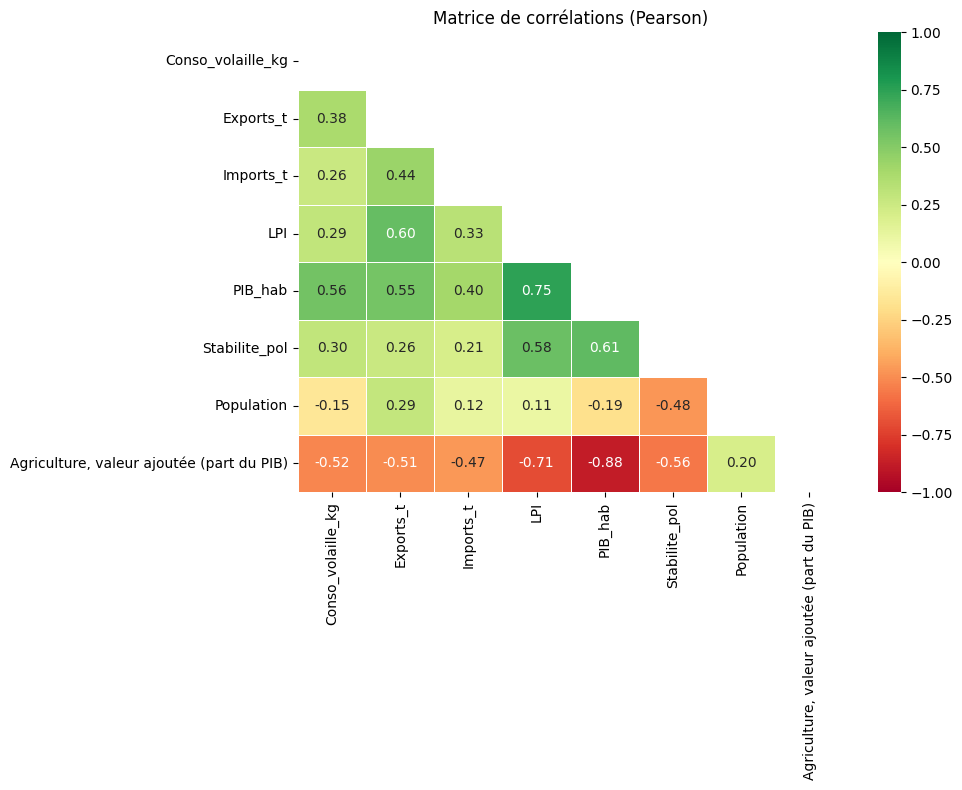

In [18]:
#Matrice de corrélations
#Anticiper les redondances entre variables — si deux variables sont très corrélées (r > 0.8), l'ACP les fusionnera sur un même axe.
corr = df_final[VARIABLES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title('Matrice de corrélations (Pearson)')
plt.tight_layout()
plt.show()

### Observations par variables

- Corrélations fortes (|r| > 0.5) :
- PIB_hab ↔ LPI (r=0.80) — Les pays riches ont une meilleure logistique. Corrélation très forte — ces deux variables porteront probablement le même axe ACP.
- PIB_hab ↔ Stabilite_pol (r=0.66) — Les pays riches sont plus stables politiquement.
- LPI ↔ Stabilite_pol (r=0.58) — stabilité et infrastructure logistique vont ensemble.
- Agriculture ↔ PIB_hab (r=-0.64) — Plus un pays est riche, moins l'agriculture pèse dans son PIB. Cohérent.
- Agriculture ↔ LPI (r=-0.57) — Les pays agricoles ont une logistique moins développée.
- Agriculture ↔ Conso_volaille_kg (r=-0.53) — Les pays très agricoles consomment moins de volaille. Peut refléter des habitudes alimentaires différentes ou une pauvreté plus élevée.

### Lecture pour l'ACP :
Un premier axe se dessine clairement autour du niveau de développement : PIB_hab, LPI, Stabilite_pol, Agriculture forment un bloc cohérent.
Population et Exports_t/Imports_t sont peu corrélés aux autres → ils apporteront de l'information indépendante sur un second axe.

In [19]:
#Skewness
skew = df_final[VARIABLES].skew().sort_values(ascending=False).round(2)
print(skew)

Exports_t                                    0.81
Conso_volaille_kg                            0.69
LPI                                          0.66
Agriculture, valeur ajoutée (part du PIB)    0.26
Population                                   0.09
Imports_t                                   -0.13
Stabilite_pol                               -0.51
PIB_hab                                     -0.54
dtype: float64


Le skewness est cohérent, toutes les variables sont sous |1|, la transformation a bien fonctionné.

## ACP

- Analyser le cercle des corrélations et la projection des individus,
- Regrouper les pays en utilisant les données de l'ACP, 
- Réaliser la classification ascendante hiérarchique,
- Réaliser un K-means. 

In [20]:
#Standardisation des données
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final[VARIABLES])
X_scaled = pd.DataFrame(X_scaled, index=df_final['Pays'], columns=VARIABLES)

In [21]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

# Variance expliquée
var_exp = pca.explained_variance_ratio_
var_cum = np.cumsum(var_exp)

print(pd.DataFrame({
    'Variance (%)': (var_exp * 100).round(1),
    'Cumulée (%)' : (var_cum * 100).round(1)
}, index=[f'PC{i+1}' for i in range(len(var_exp))]))

     Variance (%)  Cumulée (%)
PC1          50.3         50.3
PC2          19.1         69.4
PC3          10.1         79.5
PC4           8.6         88.1
PC5           5.0         93.1
PC6           3.9         97.0
PC7           1.7         98.7
PC8           1.3        100.0


On retient les axes jusqu'à 80% de variance cumulée. En dessous, l'information perdue est acceptable. Au-dessus, on garde trop de bruit.

Hypothèse avant cercle des corrélations

- PC1 (50%) — Axe du niveau de développement : PIB, LPI, Stabilité politique, Agriculture vont dans le même sens vu les corrélations. Cet axe va séparer les pays riches/stables des pays pauvres/instables.
- PC2 (19%) — Axe du commerce : probablement Imports/Exports et Population — les grands pays commerçants vs les petits.
- PC3 (10%) — Axe résiduel — capturera ce qui reste non expliqué par les deux premiers, peut-être la consommation de volaille spécifique.

In [22]:
#Eboulis et cercle de corrélation
pca2 = PCA(n_components=2)
coords_2d = pca2.fit_transform(X_scaled)
df_coords = pd.DataFrame(coords_2d, index=X_scaled.index, columns=['PC1', 'PC2'])

pca3 = PCA(n_components=3)
coords_3d = pca3.fit_transform(X_scaled)


L'éboulis (scree plot) est un graphique avec :

axe X : numéro de la composante (PC1, PC2...)
axe Y : variance expliquée (%)

On s'arrête au coude — là où la courbe s'aplatit. Après le coude, chaque axe supplémentaire apporte peu d'information nouvelle.

Deux règles combinées pour choisir le nombre d'axes

Règle 1 — Kaiser : garder les axes avec variance > 1/nb_variables = 12.5% ici
→ PC1 (50%) et PC2 (19%) passent, PC3 (10%) est limite

Règle 2 — Seuil cumulé 80%
→ PC1+PC2+PC3 = 79.5%

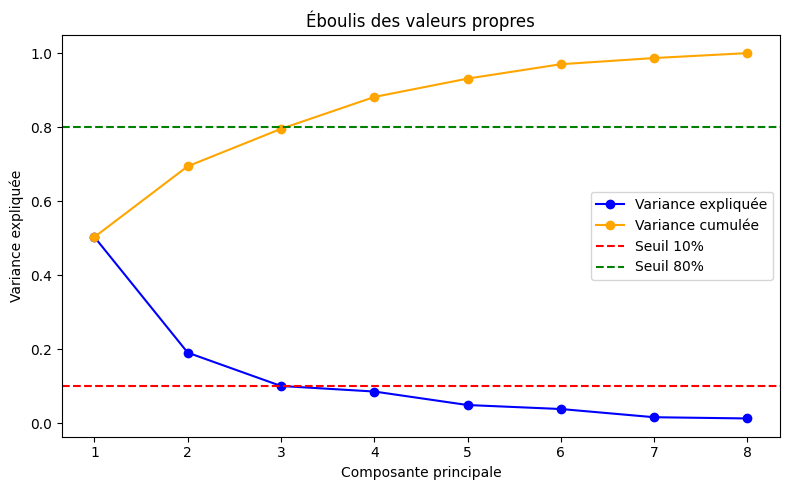

In [23]:
#Graphique éboulis
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(var_exp)+1), var_exp, 'bo-', label='Variance expliquée')
ax.plot(range(1, len(var_cum)+1), var_cum, 'o-', color='orange', label='Variance cumulée')
ax.axhline(y=0.1, color='red', linestyle='--', label='Seuil 10%')
ax.axhline(y=0.8, color='green', linestyle='--', label='Seuil 80%')
ax.set_title('Éboulis des valeurs propres')
ax.set_xlabel('Composante principale')
ax.set_ylabel('Variance expliquée')
ax.set_xticks(range(1, len(var_exp)+1))
ax.legend()
plt.tight_layout()
plt.show()

***Conclusion***
- PC1: indispensable
- PC2: apport significatif
- PC3: franchit le seuil 80%
- PC4: sous le seuil rouge, coude déjà passé

Ce graphique montre ce que chaque axe de l'ACP mesure vraiment.

1. Longueur de la flèche
Flèche longue (proche du cercle) → variable bien représentée sur ces 2 axes
Flèche courte (proche du centre) → variable mal représentée → chercher sur PC3

2. Direction de la flèche
Pointe à droite  → corrélée positivement avec PC1
Pointe à gauche  → corrélée négativement avec PC1
Pointe en haut   → corrélée positivement avec PC2
Pointe en bas    → corrélée négativement avec PC2

3. Angle entre deux flèches
Angle faible (flèches proches)  → variables corrélées entre elles
Angle ~90°                      → variables indépendantes
Angle ~180° (flèches opposées)  → variables inversement corrélées

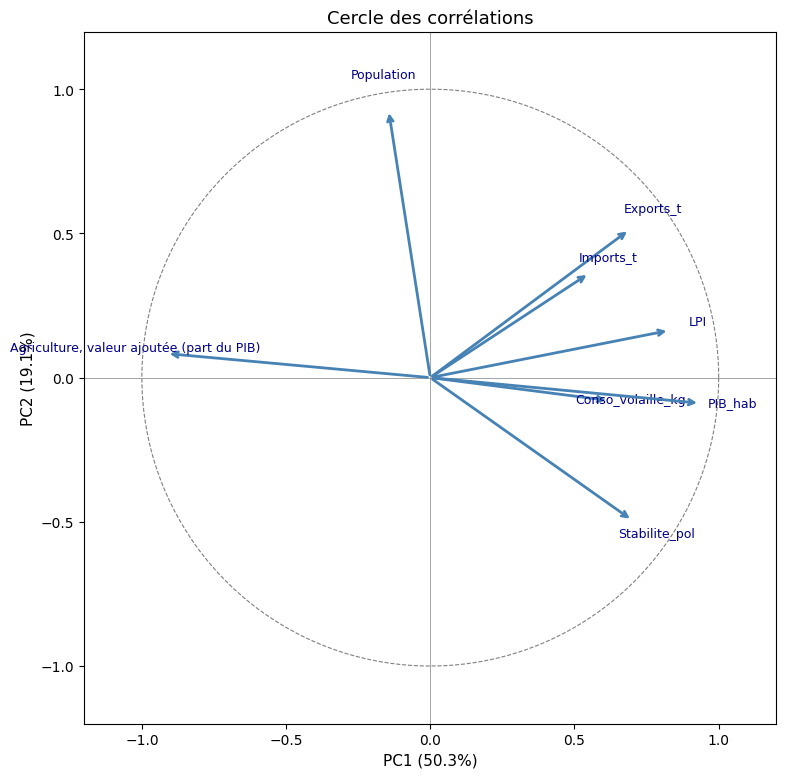

In [24]:
#Cercle des corrélations

def plot_cercle_correlations(pca, variables, title='Cercle des corrélations'):
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Corrélations variables / composantes
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    
    for i, var in enumerate(variables):
        ax.annotate('', xy=(loadings[i, 0], loadings[i, 1]), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
        ax.text(loadings[i, 0] * 1.12, loadings[i, 1] * 1.12, var,
                fontsize=9, ha='center', color='darkblue')
    
    # Cercle unité
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), 'gray', linewidth=0.8, linestyle='--')
    
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
    ax.set_title(title, fontsize=13)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

plot_cercle_correlations(pca2, VARIABLES)

## Lecture du cercle des corrélations

### PC1 (50.3%) — Axe du développement économique

Toutes les variables sont fortement projetées sur PC1 :

- **Côté droit (+)** : PIB_hab, LPI, Conso_volaille_kg, Imports_t, Exports_t → pays riches, bien connectés, gros consommateurs
- **Côté gauche (-)** : Agriculture part PIB → pays pauvres, économies agricoles

**PC1 sépare les pays développés des pays en développement.**

---

### PC2 (19.1%) — Axe taille/commerce

- **Haut (+)** : Population, Imports_t, Exports_t → grands pays très commerçants
- **Bas (-)** : Stabilite_pol → pays instables

**PC2 sépare les grands pays commerçants des pays instables.**

---

### Observations clés

**Variables très corrélées entre elles** (flèches proches) :
- PIB_hab ↔ LPI ↔ Conso_volaille_kg → quasi confondues sur PC1
- Imports_t ↔ Exports_t → même direction

**Variable indépendante** :
- Population pointe vers le haut seule → apporte une information non capturée par PC1

**Agriculture** est à l'opposé de PIB_hab → confirme la corrélation négative r=-0.64 vue plus tôt.


In [25]:
# Projection des individus sur PC1-PC2
fig = px.scatter(
    df_coords,
    x='PC1', y='PC2',
    text=df_coords.index,
    title='Projection des pays (plan PC1-PC2)',
    labels={
        'PC1': f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)'
    },
    hover_name=df_coords.index
)

fig.update_traces(
    textposition='top center',
    textfont=dict(size=7),
    marker=dict(size=6, color='steelblue')
)

fig.add_hline(y=0, line_dash='dash', line_color='gray', line_width=0.5)
fig.add_vline(x=0, line_dash='dash', line_color='gray', line_width=0.5)

fig.update_layout(height=750)
fig.show()

## Lecture de la projection des individus

### PC1 (axe horizontal) — Niveau de développement

**Droite (+)** : Allemagne, France, Irlande, Suisse, Luxembourg, Canada → pays très développés, fort PIB, bonne logistique, forte consommation volaille

**Gauche (-)** : Niger, Tchad, Nigéria, Pakistan, Inde → pays pauvres, économie agricole dominante

---

### PC2 (axe vertical) — Taille / Commerce

**Haut (+)** : Brésil, Russie, Allemagne, Inde, Pakistan → grands pays, forts volumes commerciaux

**Bas (-)** : Luxembourg, Islande, Malte, Monténégro, Fidji → petits pays, stables mais peu peuplés

---

### 4 groupes visibles à l'œil

| Quadrant | Profil | Exemples |
|---|---|---|
| Haut droite | Grands pays développés | Allemagne, France, Brésil, Russie |
| Bas droite | Petits pays riches | Luxembourg, Irlande, Suisse, Islande |
| Haut gauche | Grands pays pauvres | Inde, Pakistan, Nigéria, Indonésie |
| Bas gauche | Petits pays pauvres | Îles Salomon, Guyana, Lesotho |

---

**Pour notre étude :** les cibles export idéales sont le **quadrant haut-droite** — pays avec pouvoir d'achat élevé ET volumes d'import importants. 

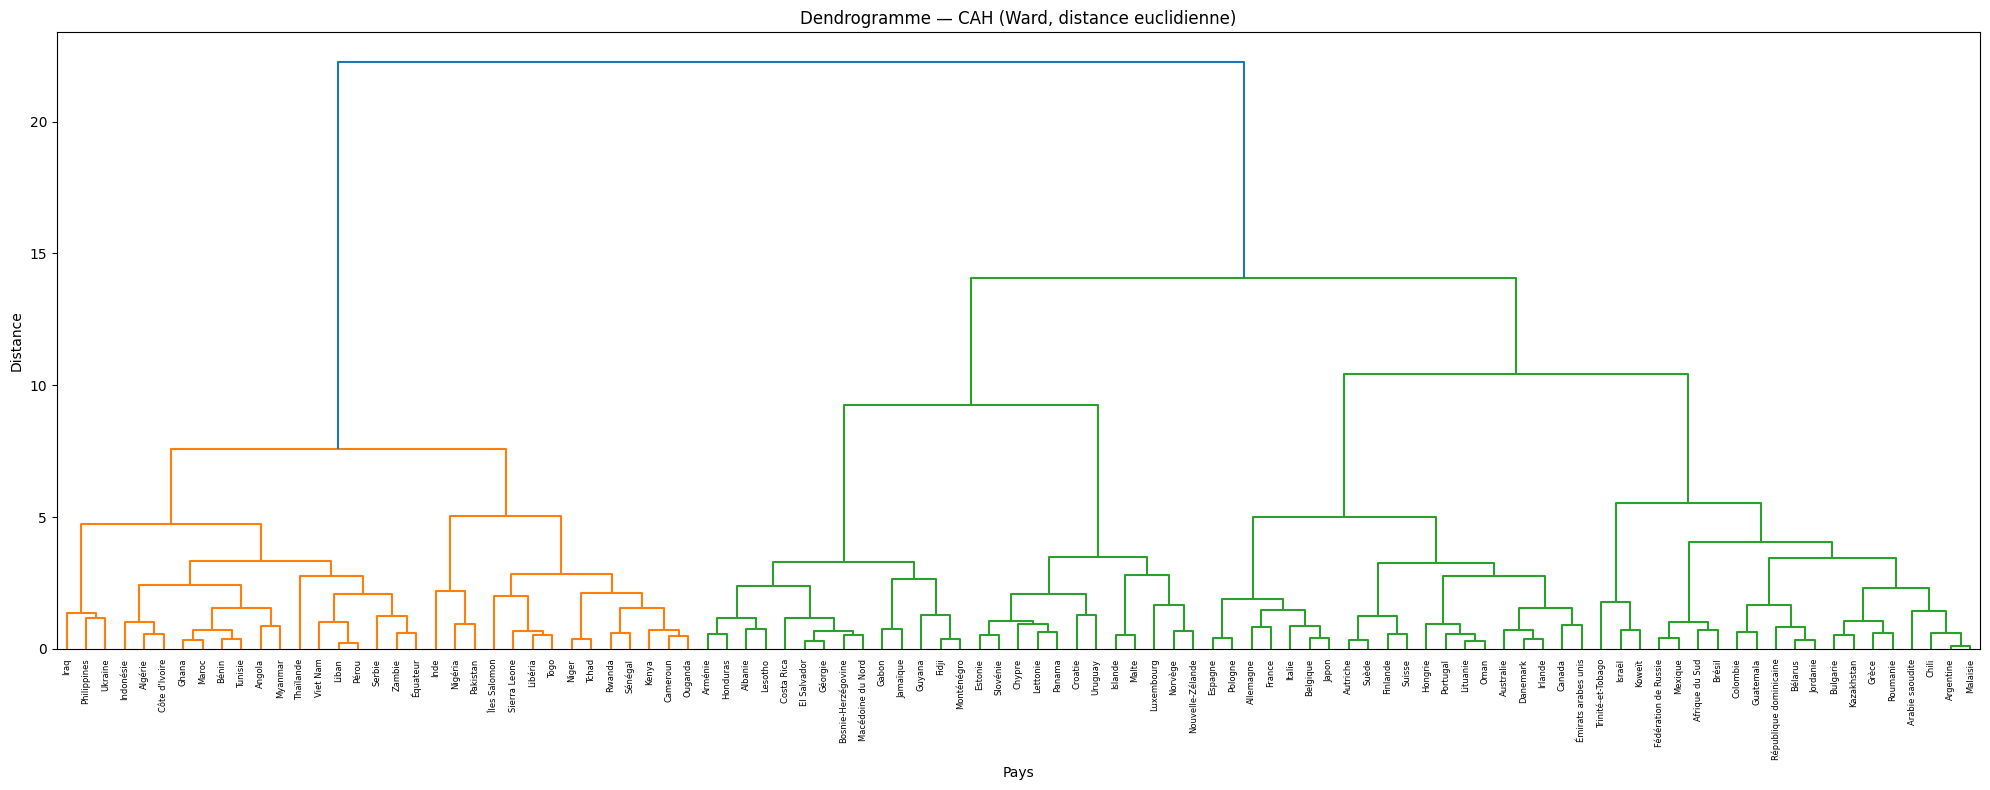

In [26]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# ── CAH sur les 3 composantes ACP ─────────────────────────────────────────────
Z = linkage(coords_3d, method='ward', metric='euclidean')

# ── Dendrogramme ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
dendrogram(
    Z,
    labels=df_coords.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=6,
    color_threshold=0.7 * max(Z[:, 2]),
    ax=ax
)
ax.set_title('Dendrogramme — CAH (Ward, distance euclidienne)')
ax.set_ylabel('Distance')
ax.set_xlabel('Pays')
plt.tight_layout()
plt.show()

## Lecture du dendrogramme

**2 grands groupes** se détachent nettement — la coupure principale est à distance ~22 (très haut) :
- **Gauche (orange)** : pays en développement
- **Droite (vert)** : pays développés

---

**À l'intérieur, on voit 4 sous-groupes naturels** (coupure vers distance ~14) :

| Cluster | Couleur | Profil visible |
|---|---|---|
| 1 | Orange gauche | Grands pays pauvres (Philippines, Inde, Indonésie, Algérie...) |
| 2 | Orange droite | Petits pays très pauvres (Niger, Tchad, Sénégal, Kenya...) |
| 3 | Vert gauche | Pays intermédiaires (Albanie, Costa Rica, Serbie, Jamaïque...) |
| 4 | Vert droite | Pays développés (France, Allemagne, Canada, Australie...) |

---

**Décision : 4 clusters**

Le saut de distance le plus important est entre 2 et 4 clusters. 4 est le choix le plus lisible et pertinent pour l'étude marché.

In [27]:
N_CLUSTERS = 4
labels_cah = fcluster(Z, N_CLUSTERS, criterion='maxclust')
df_coords['cluster_cah'] = labels_cah
df_final['cluster_cah'] = labels_cah
print(pd.Series(labels_cah).value_counts().sort_index())

1    33
2    26
3    20
4    20
Name: count, dtype: int64


In [28]:
#Projection des clusters sur le plan PC1-PC2

df_plot = df_coords.copy()
df_plot['cluster_cah'] = df_coords['cluster_cah'].astype(str)

fig = px.scatter(
    df_plot,
    x='PC1', y='PC2',
    color='cluster_cah',
    hover_name=df_plot.index,
    title=f'Clusters CAH projetés sur le plan ACP (k={N_CLUSTERS})',
    labels={
        'PC1': f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)',
        'cluster_cah': 'Cluster'
    }
)
fig.add_hline(y=0, line_dash='dash', line_color='gray', line_width=0.5)
fig.add_vline(x=0, line_dash='dash', line_color='gray', line_width=0.5)
fig.update_traces(marker=dict(size=8))
fig.update_layout(height=700)
fig.show()

## Lecture des clusters CAH

**Cluster 1 (vert — 33 pays)** — Gauche, PC2 élevé
Grands pays pauvres à forte population. PIB faible, agriculture dominante. Peu attractifs pour l'export bio.

**Cluster 2 (rouge — 26 pays)** — Dispersé, PC2 négatif
Pays instables ou très petits. Faible logistique, faible consommation volaille. Marchés risqués.

**Cluster 3 (violet — 20 pays)** — Droite, PC2 positif
Pays développés à fort commerce. Bonne logistique, PIB élevé, gros importateurs. **Cibles prioritaires.**

**Cluster 4 (bleu — 20 pays)** — Centre-droite
Pays intermédiaires émergents. PIB moyen, logistique correcte. **Cibles secondaires à surveiller.**

---

**Observation :** les clusters ne sont pas parfaitement séparés sur le plan PC1-PC2 — normal, le clustering a été fait sur 3 axes (79.5% de variance) et on ne visualise que 2 axes (69.4%).

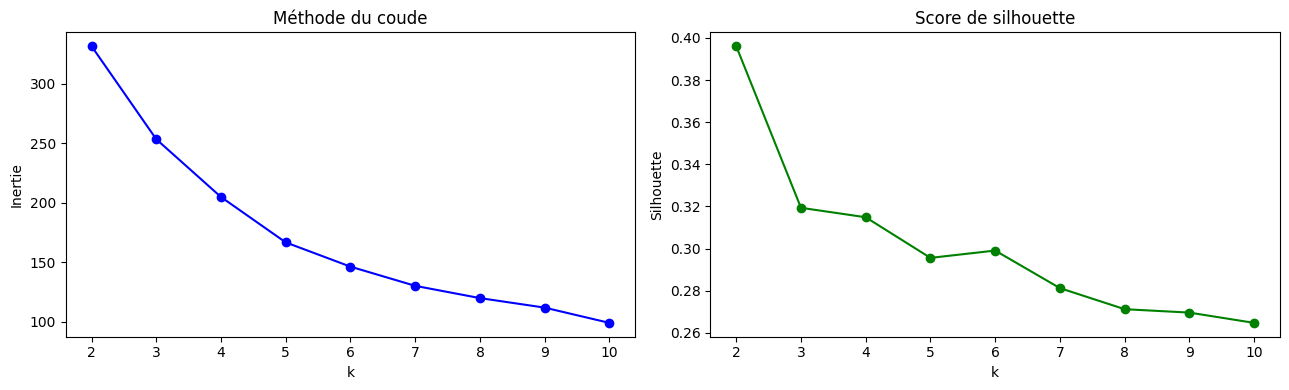

k optimal (silhouette) : 2


In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Méthode du coude + silhouette ─────────────────────────────────────────────
inertias    = []
silhouettes = []
K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords_3d)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(coords_3d, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(K_RANGE, inertias, 'bo-')
ax1.set_title('Méthode du coude')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertie')
ax1.set_xticks(list(K_RANGE))

ax2.plot(K_RANGE, silhouettes, 'go-')
ax2.set_title('Score de silhouette')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette')
ax2.set_xticks(list(K_RANGE))

plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
print(f'k optimal (silhouette) : {best_k}')

## Lecture des graphiques

**Méthode du coude :** pas de coude franc — la courbe descend progressivement sans rupture nette. On peut voir une légère inflexion à **k=4 ou k=5**.

**Silhouette :** k=2 est mathématiquement optimal (0.39) mais trop peu discriminant pour une étude marché. La courbe chute puis se stabilise à partir de k=5.

---

## Décision

Les deux méthodes ne convergent pas clairement. On va **retenir k=4** pour :
- Cohérence avec la CAH qui suggérait 4 clusters
- Meilleure granularité pour l'étude marché (2 clusters = trop grossier)
- Inflexion visible du coude à k=4

In [30]:
K_FINAL = 4

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
labels_km = km_final.fit_predict(coords_3d)

df_coords['cluster_km'] = labels_km + 1
df_final['cluster_km']  = labels_km + 1

print('Répartition K-means :')
print(pd.Series(labels_km + 1).value_counts().sort_index())

Répartition K-means :
1    25
2    30
3    25
4    19
Name: count, dtype: int64


Répartition équilibrée — similaire à la CAH.

| Cluster | Pays |
|---|---|
| 1 | 25 |
| 2 | 30 |
| 3 | 25 |
| 4 | 19 |

In [31]:
df_plot = df_coords.copy()
df_plot['cluster_km'] = df_coords['cluster_km'].astype(str)

fig = px.scatter(
    df_plot,
    x='PC1', y='PC2',
    color='cluster_km',
    hover_name=df_plot.index,
    title=f'Clusters K-means projetés sur le plan ACP (k={K_FINAL})',
    labels={
        'PC1': f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)',
        'PC2': f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)',
        'cluster_km': 'Cluster'
    }
)
fig.add_hline(y=0, line_dash='dash', line_color='gray', line_width=0.5)
fig.add_vline(x=0, line_dash='dash', line_color='gray', line_width=0.5)
fig.update_traces(marker=dict(size=8))
fig.update_layout(height=700)
fig.show()

In [32]:
profil = df_final.groupby('cluster_km')[VARIABLES].mean().round(2)
profil

,Conso_volaille_kg,Exports_t,Imports_t,LPI,PIB_hab,Stabilite_pol,Population,"Agriculture, valeur ajoutée (part du PIB)"
cluster_km,,,,,,,,
1,25.74,3.20,4.46,2.72,9.90,-0.47,10.28,1.85
2,9.00,0.27,1.82,2.36,8.55,-0.60,9.88,2.88
3,28.28,1.28,2.51,2.87,10.37,0.48,7.64,1.47
4,25.52,4.51,4.87,3.84,10.88,0.78,9.76,0.95


## Profil des clusters

Les variables sont en log — les valeurs sont donc des ordres de grandeur relatifs.

---

**Cluster 4 — Cibles prioritaires** (19 pays)
- PIB le plus élevé (10.88), meilleure stabilité (0.78), meilleur LPI (3.84)
- Forts importateurs (4.87) et exportateurs (4.51)
- Agriculture faible (0.95) → peu autosuffisants
- Forte consommation volaille (25.52 kg/hab)

**Cluster 3 — Cibles secondaires** (25 pays)
- PIB élevé (10.37), stabilité positive (0.48)
- Consommation volaille la plus haute (28.28 kg/hab) → habitude de consommation forte
- Imports modérés → marché moins ouvert que cluster 4

**Cluster 1 — Marchés émergents** (25 pays)
- PIB intermédiaire, stabilité négative (-0.47)
- Forts imports (4.46) malgré PIB plus faible → dépendance aux importations
- Agriculture élevée (1.85)

**Cluster 2 — Non prioritaires** (30 pays)
- PIB le plus faible (8.55), stabilité négative (-0.60)
- Faible consommation volaille (9.00 kg/hab)
- Agriculture dominante (2.88)

---

**Conclusion pour l'export bio :** Cluster 4 en priorité, Cluster 3 en second.

In [33]:
for k in sorted(df_final['cluster_km'].unique()):
    pays_list = df_final[df_final['cluster_km'] == k]['Pays'].tolist()
    print(f'\n── Cluster {k} ({len(pays_list)} pays) ──')
    print(', '.join(sorted(pays_list)))


── Cluster 1 (25 pays) ──
Afrique du Sud, Arabie saoudite, Argentine, Brésil, Bulgarie, Bélarus, Chili, Colombie, Fédération de Russie, Grèce, Guatemala, Géorgie, Iraq, Jordanie, Kazakhstan, Liban, Malaisie, Mexique, Philippines, Pérou, Roumanie, République dominicaine, Thaïlande, Ukraine, Viet Nam

── Cluster 2 (30 pays) ──
Albanie, Algérie, Angola, Arménie, Bénin, Cameroun, Côte d'Ivoire, El Salvador, Ghana, Honduras, Inde, Indonésie, Kenya, Lesotho, Libéria, Maroc, Myanmar, Niger, Nigéria, Ouganda, Pakistan, Rwanda, Sierra Leone, Sénégal, Tchad, Togo, Tunisie, Zambie, Équateur, Îles Salomon

── Cluster 3 (25 pays) ──
Bosnie-Herzégovine, Chypre, Costa Rica, Croatie, Estonie, Fidji, Gabon, Guyana, Islande, Israël, Jamaïque, Koweït, Lettonie, Lituanie, Luxembourg, Macédoine du Nord, Malte, Monténégro, Norvège, Nouvelle-Zélande, Panama, Serbie, Slovénie, Trinité-et-Tobago, Uruguay

── Cluster 4 (19 pays) ──
Allemagne, Australie, Autriche, Belgique, Canada, Danemark, Espagne, Finlande, 

## Résumé de l'analyse

---

**99 pays et 8 informations par pays** (richesse, stabilité, consommation de poulet, imports/exports...).

---

**Étape 1 — Simplification de l'information (ACP)**

Le premier indicateur résume surtout **la richesse du pays** (PIB, logistique, stabilité). Le deuxième résume la taille et le commerce.

---

**Étape 2 — Regroupement des pays qui se ressemblent (CAH)**

La CAH regroupe les pays ayant le plus de similaritude en commençant par regrouper les plus proches puis en élargissant progressivement. Le dendrogramme est l'arbre généalogique de ces regroupements.

L'arbre est divisé en 4 groupes.

---

**Étape 3 — Vérification des résultats avec le K-means**

Le K-means fonctionne différemment mais permet de confirmer les résultats.

Les deux méthodes ont trouvé **la même structure à 4 groupes**.

---

**Résultat — 4 groupes de pays**

| Groupe | Profil | Intérêt |
|---|---|---|
| Cluster 4 | Pays riches, stables, gros importateurs | ⭐⭐⭐ Prioritaire |
| Cluster 3 | Pays développés, forte consommation volaille | ⭐⭐ Secondaire |
| Cluster 1 | Pays émergents, dépendants des imports | ⭐ À surveiller |
| Cluster 2 | Pays pauvres, instables | ✗ Non prioritaire |